In [20]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import doctest

In [21]:
def load_data(dataset_name, x_name, y_name):
    """

    >>> pass
    """
    data = sns.load_dataset(dataset_name)
    print(type(data), data.shape)
    print(data.head())
    print(data.describe())
    print(data.info())
    sns.scatterplot(data, y="total_bill", x='tip')
    x_data = np.array(data[x_name])
    y_data = np.array(data[y_name])

    one = np.ones(len(y_data))
    """
    one = np.array([1, 1, 1, 1, 1]) x_data = np.array([10, 20, 30, 40, 50])
    [[ 1 10]
     [ 1 20]
     [ 1 30]
     [ 1 40]
     [ 1 50]]
    np.row_stack((a, b)) row
    np.hstack((a, b))	horizontal
    np.vstack((a, b))
    """
    x_train = np.column_stack((one, x_data))
    print(x_train.shape,x_data.shape, y_data.shape)
    return x_train, x_data, y_data


<class 'pandas.DataFrame'> (244, 7)
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000
<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 

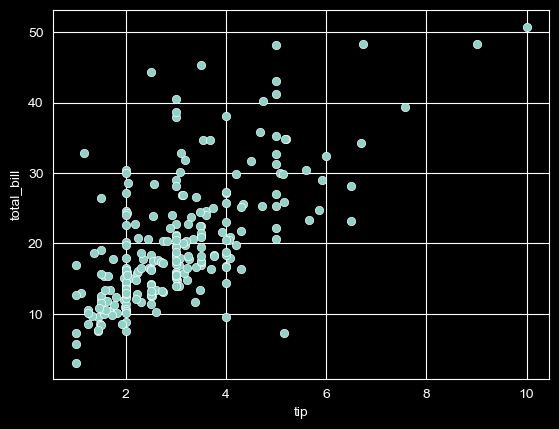

In [22]:
doctest.testmod()
train_data_x, total_bill, tip = load_data("tips", "total_bill", "tip")

print(np.eye(4))
# [[0. 1. 0. 0.]
#  [0. 0. 1. 0.]
#  [0. 0. 0. 1.]
np.diag([1, 1, 1])


In [23]:
# wᵢ = exp(-‖xᵢ - x‖²/(2τ²)),
def weight_matrix(point, x_train, tau):
    m = len(x_train)
    # np.eye(N, M=None, k=0, dtype=float), create identity matrix,  diag = 1,others 0. N rows, M column = row
    weights = np.eye(m)
    for i  in range(m):
        diff = point - x_train[i]
        weights[i, i] = np.exp(diff @ diff.T / (-2.0 * tau**2))
    return weights


In [24]:
# β = (XᵀWX)⁻¹(XᵀWy)
def local_weight(point, x_train, y_train, tau):
    weight_mat = weight_matrix(point, x_train, tau)
    XT = x_train.T
    XTWX = XT @ weight_mat @ x_train
    XTWy = XT @ weight_mat @ y_train

    beta = np.linalg.inv(XTWX) @ XTWy

    return beta


In [25]:
# ^y = βx
def locally_weight_regression(x_train, y_train, tau):
    """
    >>> pass
    """
    # x_train.shape = (244, 2)
    # print(x_train.shape, len(x_train))
    y_pred = np.zeros(len(x_train))
    for i,  item in enumerate(x_train):
        y_pred[i] = np.dot(item,  local_weight(item, x_train, y_train, tau)).item()
    return y_pred

In [26]:
predictions = locally_weight_regression(train_data_x, tip, 5)

In [27]:
print(predictions)

[2.75518942 1.90689756 3.23908926 3.4988944  3.57651396 3.63320621
 1.74202948 3.7547357  2.49661266 2.46196262 1.8991095  4.30668582
 2.54730317 2.93924038 2.46862202 3.29893372 1.90578257 2.66304776
 2.75257544 3.20003989 2.87511356 3.16003461 2.59396124 4.53536564
 3.10640323 2.86111574 2.27606292 2.18866741 3.3112216  3.08662508
 1.82133869 2.92926975 2.4992798  3.20442623 2.85728858 3.53189499
 2.66569632 2.74734374 2.97140193 4.0667562  2.62988121 2.81622351
 2.35063798 1.8350606  4.00673436 2.92176945 3.36420768 4.14189437
 3.87596986 2.89031915 2.16967089 1.90133064 4.28351964 1.86293059
 3.65447599 3.06783159 4.44327761 3.71964874 2.01040548 6.82750291
 3.16003461 2.33354342 1.98454458 2.92176945 2.83295812 3.13626489
 2.68421368 1.26544418 3.1532755  2.4926123  2.10473804 2.76563252
 3.75325396 3.63241248 2.45530566 1.92597404 2.87511356 3.77832341
 3.41513414 2.79423932 3.06192366 2.71190728 1.8770764  4.15981052
 2.62190676 4.28456924 2.23211989 2.92051756 3.58640418 3.2550

In [28]:
def plot_preds(x_train, preds, x_data, y_data, x_name, y_name):
    x_train_sorted = np.sort(x_train, axis = 0)
    plt.scatter(x_data, y_data, color="blue")
    plt.plot(
        x_train_sorted[:, 1],
        preds[x_train[:, 1].argsort(0)],
        color="yellow",
        linewidth=5
    )
    plt.xlabel(x_name)
    plt.ylabel(y_name)
    plt.show()

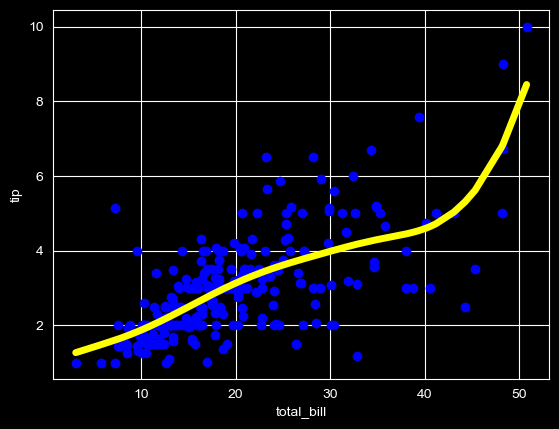

In [29]:
plot_preds(train_data_x, predictions, total_bill, tip, "total_bill", "tip")

In [30]:
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import train_test_split


In [31]:
class LocallyWeightedRegression(BaseEstimator, RegressorMixin):
    def __init__(self, tau=5.0):
        self.tau = tau

    def fit(self, X, y):
        # 如果 X 是一维数组，添加偏置项变成 [1, x] 的形式
        if X.ndim == 1:
            self.X_train = np.column_stack([np.ones(len(X)), X])
        else:
            self.X_train = X
        self.y_train = y
        return self

    def predict(self, X):
        # 如果 X 是一维数组，添加偏置项
        if X.ndim == 1:
            X = np.column_stack([np.ones(len(X)), X])

        y_pred = []
        for x_q in X:
            # 计算权重：基于特征值（不包括偏置项）的距离
            weights = np.exp(-np.sum((self.X_train[:, 1:] - x_q[1:])**2, axis=1) / (2 * self.tau**2))
            W = np.diag(weights)
            # 计算局部加权回归系数：β = (XᵀWX)⁻¹XᵀWy
            XTWX = self.X_train.T @ W @ self.X_train
            XTWy = self.X_train.T @ W @ self.y_train
            beta = np.linalg.inv(XTWX) @ XTWy
            # 预测：y = x_q · beta
            y_pred.append(np.dot(x_q, beta))
        return np.array(y_pred)


In [32]:
# train_data_x, total_bill, tip
lwr = LocallyWeightedRegression(tau=5)
lwr.fit(total_bill, tip)
y_pred = lwr.predict(train_data_x)



In [33]:
print(y_pred)

[2.75518942 1.90689756 3.23908926 3.4988944  3.57651396 3.63320621
 1.74202948 3.7547357  2.49661266 2.46196262 1.8991095  4.30668582
 2.54730317 2.93924038 2.46862202 3.29893372 1.90578257 2.66304776
 2.75257544 3.20003989 2.87511356 3.16003461 2.59396124 4.53536564
 3.10640323 2.86111574 2.27606292 2.18866741 3.3112216  3.08662508
 1.82133869 2.92926975 2.4992798  3.20442623 2.85728858 3.53189499
 2.66569632 2.74734374 2.97140193 4.0667562  2.62988121 2.81622351
 2.35063798 1.8350606  4.00673436 2.92176945 3.36420768 4.14189437
 3.87596986 2.89031915 2.16967089 1.90133064 4.28351964 1.86293059
 3.65447599 3.06783159 4.44327761 3.71964874 2.01040548 6.82750291
 3.16003461 2.33354342 1.98454458 2.92176945 2.83295812 3.13626489
 2.68421368 1.26544418 3.1532755  2.4926123  2.10473804 2.76563252
 3.75325396 3.63241248 2.45530566 1.92597404 2.87511356 3.77832341
 3.41513414 2.79423932 3.06192366 2.71190728 1.8770764  4.15981052
 2.62190676 4.28456924 2.23211989 2.92051756 3.58640418 3.2550

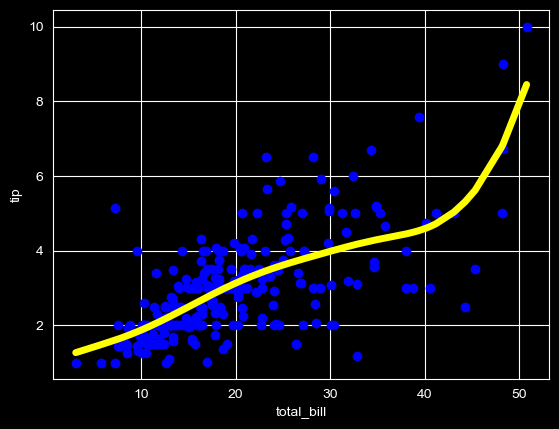

In [34]:
plot_preds(train_data_x, y_pred, total_bill, tip, "total_bill", "tip")


In [35]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
y_true = tip

y_pred_func = locally_weight_regression(train_data_x, tip, 5)
lwr = LocallyWeightedRegression(tau=5)
lwr.fit(total_bill, tip)
y_pred_class = lwr.predict(total_bill)

In [36]:
mse_func = mean_squared_error(y_true, y_pred_func)
mse_class = mean_squared_error(y_true, y_pred_class)
print(f"MSE - func: {mse_func:.4f}, class: {mse_class:.4f}")

MSE - func: 0.9465, class: 0.9465


In [37]:
mae_func = mean_absolute_error(y_true, y_pred_func)
mae_class = mean_absolute_error(y_true, y_pred_class)
print(f"MAE - func: {mae_func:.4f}, class: {mae_class:.4f}")


MAE - func: 0.7165, class: 0.7165


In [38]:
r2_func = r2_score(y_true, y_pred_func)
r2_class = r2_score(y_true, y_pred_class)
print(f"R² - func: {r2_func:.4f}, class: {r2_class:.4f}")

R² - func: 0.5035, class: 0.5035
